In [5]:
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
#Load dataset
df = pd.read_csv("C:/Users/kowsa/Downloads/funnel_events_sample.csv")
print(df)

    user_id                step            timestamp
0      U041      signup_started  2026-07-20 03:55:00
1      U098      signup_started  2026-07-20 04:19:00
2      U051      signup_started  2026-07-20 04:02:00
3      U115        visited_site  2026-07-20 04:00:00
4      U099        visited_site  2026-07-20 03:48:00
..      ...                 ...                  ...
537    U086      email_verified  2026-07-20 04:53:00
538    U094      email_verified  2026-07-20 04:47:00
539    U030      details_filled  2026-07-20 04:03:00
540    U119      signup_started  2026-07-20 04:12:00
541    U107  purchase_completed  2026-07-20 04:54:00

[542 rows x 3 columns]


In [17]:
#convert timestamp
df["timestamp"]=pd.to_datetime(df["timestamp"])
print(df["timestamp"])

0     2026-07-20 03:55:00
1     2026-07-20 04:19:00
2     2026-07-20 04:02:00
3     2026-07-20 04:00:00
4     2026-07-20 03:48:00
              ...        
537   2026-07-20 04:53:00
538   2026-07-20 04:47:00
539   2026-07-20 04:03:00
540   2026-07-20 04:12:00
541   2026-07-20 04:54:00
Name: timestamp, Length: 542, dtype: datetime64[ns]


In [23]:
# Define the correct funnel order
funnel_order = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]


In [25]:
# Remove duplicate user-stage events
df_clean=df.drop_duplicates(subset=["user_id","step"])
df_clean

,user_id,step,timestamp
0,U041,signup_started,2026-07-20 03:55:00
1,U098,signup_started,2026-07-20 04:19:00
2,U051,signup_started,2026-07-20 04:02:00
3,U115,visited_site,2026-07-20 04:00:00
4,U099,visited_site,2026-07-20 03:48:00
...,...,...,...
537,U086,email_verified,2026-07-20 04:53:00
538,U094,email_verified,2026-07-20 04:47:00
539,U030,details_filled,2026-07-20 04:03:00
540,U119,signup_started,2026-07-20 04:12:00


In [27]:
# Count unique users at each stage
funnel = (df_clean.groupby("step")["user_id"].nunique().reindex(funnel_order).reset_index())
funnel.columns = ["stage", "unique_users"]
print(funnel)

                stage  unique_users
0        visited_site           200
1      signup_started           150
2      details_filled            96
3      email_verified            52
4  purchase_completed            44


In [41]:
# Calculate previous stage users
funnel["previous_stage_users"] = funnel["unique_users"].shift(1)
print(funnel["previous_stage_users"])

0      NaN
1    200.0
2    150.0
3     96.0
4     52.0
Name: previous_stage_users, dtype: float64


In [43]:
# Calculate conversion rate
funnel["conversion_rate"] = (funnel["unique_users"] /funnel["previous_stage_users"] * 100)
print(funnel["conversion_rate"])

0          NaN
1    75.000000
2    64.000000
3    54.166667
4    84.615385
Name: conversion_rate, dtype: float64


In [45]:
# Calculate drop-off
funnel["drop_off"] = (funnel["previous_stage_users"] -funnel["unique_users"])
print(funnel["drop_off"])

0     NaN
1    50.0
2    54.0
3    44.0
4     8.0
Name: drop_off, dtype: float64


In [51]:
# First stage has no previous stage
funnel.loc[0, "conversion_rate"] = 100
funnel.loc[0, "drop_off"] = 0

funnel

,stage,unique_users,previous_stage_users,conversion_rate,drop_off
0,visited_site,200,NaN,100.000000,0.0
1,signup_started,150,200.0,75.000000,50.0
2,details_filled,96,150.0,64.000000,54.0
3,email_verified,52,96.0,54.166667,44.0
4,purchase_completed,44,52.0,84.615385,8.0


In [59]:
#identify the biggest drop-off
biggest_dropoff = funnel.iloc[1:].loc[funnel.iloc[1:]["drop_off"].idxmax()]
print("Biggest Drop-off Stage:", biggest_dropoff["stage"])
print("Users Lost:", int(biggest_dropoff["drop_off"]))
print("Conversion Rate:", round(biggest_dropoff["conversion_rate"], 2), "%")

Biggest Drop-off Stage: details_filled
Users Lost: 54
Conversion Rate: 64.0 %


In [61]:
#A better presentation is to identify the transition:
funnel["previous_stage"] = funnel["stage"].shift(1)
biggest_dropoff = funnel.iloc[1:].loc[funnel.iloc[1:]["drop_off"].idxmax()]

print(f"Biggest drop-off: {biggest_dropoff['previous_stage']} "f"→ {biggest_dropoff['stage']}")

Biggest drop-off: signup_started → details_filled


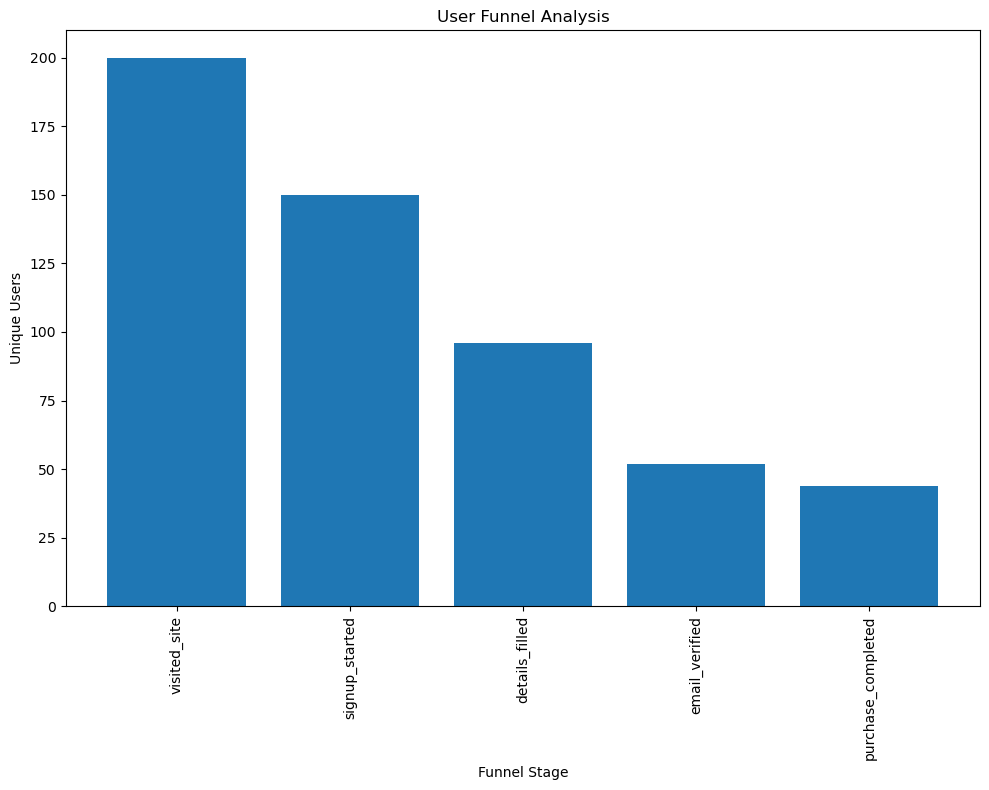

In [73]:
#Create a simple funnel chart
plt.figure(figsize=(10, 8))
plt.bar(funnel["stage"],funnel["unique_users"])

plt.title("User Funnel Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Users")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()